# Validating a Model Before Deployment

Pre-deployment validation is a gate check, not a training evaluation. It answers the question: "Is this model safe and fast enough to put in front of real users?" This notebook defines acceptance criteria, tests a trained model against them, and wraps everything in a `validate_model()` function that returns a clear pass/fail result.

**Learning objectives**
1. Distinguish pre-deployment validation from training-time evaluation.
2. Define acceptance criteria: accuracy threshold, latency budget, no NaN outputs.
3. Test a model against a held-out validation set, a latency benchmark, and malformed inputs.
4. Write a `validate_model()` function that returns a structured pass/fail report.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 2, lesson 01 "01. Cross-Validation for Model Evaluation" — cross-validation told you how good a model is; this lesson turns that number into a release gate, with a latency budget and a malformed-input check bolted onto it.


## 📰 The sepsis model that hundreds of hospitals trusted

Epic's Sepsis Model is a proprietary early-warning score deployed across hundreds of US hospitals. Its vendor documentation reported an AUC in the range **0.76–0.83**. In 2021, Wong and colleagues published an external validation in *JAMA Internal Medicine*: **27,697 patients across 38,455 hospitalizations** at Michigan Medicine between December 2018 and October 2019. Measured on that real population, the model's hospitalization-level AUC was **0.63**. It fired an alert on 18% of all hospitalizations — and still failed to identify **1,709 of the patients who developed sepsis, about 67%**.

Nothing was broken. The model loaded, responded, and produced well-formed scores every time. It had simply never been validated as a *deployment decision* on the population that would receive it — only as a *training result* on the population that produced it.

**What goes wrong without this lesson.** Training-time evaluation asks "did the model learn?". Deployment validation asks a different question — "is this specific artifact, on this specific data, fast enough and safe enough to put in front of real people?" — and the answer is a yes or a no, not a number to improve. Skip the gate and the model that ships is whichever one happened to be in the folder, judged by whichever metric happened to look good.

## 1  What is pre-deployment validation?

During training you optimize a loss function. Pre-deployment validation is different: it checks whether the trained model meets *business and operational requirements* before serving real users. You set a threshold, run the model against a held-out set it has never seen, and either deploy or reject. This is a one-shot gate, not a learning step.


In [1]:
# WHAT: build a train/validation/test split, train a pipeline, save the artifact.
# WHY: the validation set is reserved for the DEPLOYMENT GATE — a decision set the
# model never trained on, so the gate cannot be gamed by memorization.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import time
import json

iris = load_iris()

# Three-way split: train / validation / test
# Validation is used only for the deployment gate — never during training
X_train, X_temp, y_train, y_temp = train_test_split(
    iris.data, iris.target, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scaler + forest in one pipeline: the artifact under validation is the real thing.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
pipeline.fit(X_train, y_train)

# Save to disk — the gate below validates the SAVED artifact, as production would.
MODEL_PATH = "/tmp/val_pipeline.joblib"
joblib.dump(pipeline, MODEL_PATH)

print(f"Training samples  : {len(X_train)}")
print(f"Validation samples: {len(X_val)}  (used for deployment gate)")
print(f"Test samples      : {len(X_test)}  (held out entirely)")
print(f"Training accuracy : {pipeline.score(X_train, y_train):.2%}")

Training samples  : 90
Validation samples: 30  (used for deployment gate)
Test samples      : 30  (held out entirely)
Training accuracy : 100.00%


## 2  Define acceptance criteria

Acceptance criteria are set before validation runs — not after seeing the results. Setting them after the fact is "p-hacking" for ML.


In [2]:
# WHAT: write down the acceptance criteria BEFORE looking at any validation result.
# WHY: criteria chosen after seeing the numbers always pass — fixing them upfront
# is what makes the gate honest (same idea as pre-registered experiments).
# These criteria are defined upfront — not tuned after seeing validation results
CRITERIA = {
    "min_accuracy": 0.90,        # Model must get >= 90% on the held-out validation set
    "max_p95_latency_ms": 100.0, # 95th-percentile single-prediction latency must be < 100 ms
    "allow_nan_output": False,   # Model must never return NaN predictions
    "n_latency_samples": 200,    # Number of single-sample predictions to benchmark
}

print("Acceptance criteria:")
for k, v in CRITERIA.items():
    print(f"  {k}: {v}")

Acceptance criteria:
  min_accuracy: 0.9
  max_p95_latency_ms: 100.0
  allow_nan_output: False
  n_latency_samples: 200


## 3  Accuracy gate — run against the validation set


In [3]:
# WHAT: load the saved artifact and apply the accuracy gate on the validation set.
# WHY: we test the file on disk, not the in-memory object — a corrupted or stale
# artifact should fail HERE, before it ever reaches users.
model = joblib.load(MODEL_PATH)

val_preds = model.predict(X_val)
val_accuracy = float(np.mean(val_preds == y_val))

# Compare against the pre-committed threshold and report PASS/FAIL explicitly.
accuracy_pass = val_accuracy >= CRITERIA["min_accuracy"]
print(f"Validation accuracy : {val_accuracy:.2%}")
print(f"Threshold           : {CRITERIA['min_accuracy']:.0%}")
print(f"Accuracy gate       : {'PASS' if accuracy_pass else 'FAIL'}")

Validation accuracy : 100.00%
Threshold           : 90%
Accuracy gate       : PASS


## 4  Latency gate — time 200 single-sample predictions

We predict one sample at a time (not a batch) because production usually receives individual requests. We measure p95 to catch tail latency — the slow cases that actually affect users.


In [4]:
# WHAT: time 200 single-sample predictions and apply the p95 latency gate.
# WHY: accuracy is not enough — a correct model that answers in 2 seconds still
# fails users. Single-sample calls mimic real-time API traffic, not batch scoring.
latencies_ms = []
n = CRITERIA["n_latency_samples"]

# Cycle through validation rows so timing is not dominated by one cached input.
for i in range(n):
    sample = X_val[i % len(X_val)].reshape(1, -1)
    t0 = time.perf_counter()
    model.predict(sample)
    latencies_ms.append((time.perf_counter() - t0) * 1000)

# p95 is the gate metric: 19 of 20 requests must beat the threshold.
lat = np.array(latencies_ms)
p95 = float(np.percentile(lat, 95))
latency_pass = p95 < CRITERIA["max_p95_latency_ms"]

print(f"Predictions timed : {n}")
print(f"  p50             : {np.percentile(lat, 50):.2f} ms")
print(f"  p95             : {p95:.2f} ms")
print(f"  p99             : {np.percentile(lat, 99):.2f} ms")
print(f"Latency threshold : {CRITERIA['max_p95_latency_ms']:.0f} ms (p95)")
print(f"Latency gate      : {'PASS' if latency_pass else 'FAIL'}")

Predictions timed : 200
  p50             : 2.12 ms
  p95             : 2.42 ms
  p99             : 2.81 ms
Latency threshold : 100 ms (p95)
Latency gate      : PASS


## 5  Input validation — test with malformed inputs

A robust model serving layer must not crash on bad input. Here we test how the pipeline handles inputs that should never reach a production model but sometimes do.


In [5]:
# WHAT: probe the model with malformed inputs (wrong shape, NaN, empty batch).
# WHY: production traffic WILL contain garbage — we document how the model fails so
# the API layer knows exactly which errors it must catch before calling predict.
from typing import List

# Wrapper that converts exceptions into printable strings instead of crashing the cell.
def safe_predict(model, X):
    """Try to predict; return an error string if it fails."""
    try:
        return model.predict(X)
    except Exception as e:
        return f"ERROR: {type(e).__name__}: {e}"

# Wrong number of features
wrong_shape = np.array([[5.1, 3.5]])  # only 2 features instead of 4
result_a = safe_predict(model, wrong_shape)
print(f"Wrong shape (2 features): {result_a}")

# NaN values in input
nan_input = np.array([[5.1, np.nan, 1.4, 0.2]])
result_b = safe_predict(model, nan_input)
print(f"NaN in input            : {result_b}")

# Empty array
empty_input = np.array([]).reshape(0, 4)
result_c = safe_predict(model, empty_input)
print(f"Empty input             : {result_c}")

print("\nInput validation checks complete — errors above are expected and should be caught at the API layer.")

Wrong shape (2 features): ERROR: ValueError: X has 2 features, but StandardScaler is expecting 4 features as input.
NaN in input            : [0]
Empty input             : ERROR: ValueError: Found array with 0 sample(s) (shape=(0, 4)) while a minimum of 1 is required by StandardScaler.

Input validation checks complete — errors above are expected and should be caught at the API layer.


## 6  Output validation — check shape, ranges, and NaN


In [6]:
# Valid predictions on the validation set
preds = model.predict(X_val)
probas = model.predict_proba(X_val)

# Output shape checks
assert preds.shape == (len(X_val),), f"Wrong output shape: {preds.shape}"
assert probas.shape == (len(X_val), 3), f"Wrong proba shape: {probas.shape}"

# Value range checks
assert not np.any(np.isnan(preds)), "NaN in predictions"
assert not np.any(np.isnan(probas)), "NaN in probability outputs"
assert np.all(probas >= 0) and np.all(probas <= 1), "Probabilities out of [0, 1]"

# Probabilities must sum to 1 per sample
row_sums = probas.sum(axis=1)
assert np.allclose(row_sums, 1.0, atol=1e-6), f"Probabilities don't sum to 1: {row_sums[:5]}"

# Predictions must be valid class indices
valid_classes = set(range(3))
assert set(preds).issubset(valid_classes), f"Unexpected class values: {set(preds)}"

no_nan_pass = not (np.any(np.isnan(preds)) or np.any(np.isnan(probas)))

print("Output shape  : PASS")
print("No NaN output : PASS")
print("Proba range   : PASS")
print("Proba sums    : PASS")
print("Valid classes : PASS")


Output shape  : PASS
No NaN output : PASS
Proba range   : PASS
Proba sums    : PASS
Valid classes : PASS


## 7  `validate_model()` — the deployment gate function


In [7]:
# WHAT: combine accuracy, latency, and NaN checks into one reusable gate function
# that returns a structured report.
# WHY: this is the notebook's payoff — a single validate_model() call a CI pipeline
# could run on every new artifact, with machine-readable pass/fail per check.
def validate_model(model, X_val, y_val, criteria):
    """
    Run all deployment validation checks and return a structured report.
    Returns a dict with 'passed' (bool) and 'checks' (per-check results).
    """
    report = {"passed": True, "checks": {}}

    # 1. Accuracy
    preds = model.predict(X_val)
    accuracy = float(np.mean(preds == y_val))
    acc_ok = accuracy >= criteria["min_accuracy"]
    report["checks"]["accuracy"] = {
        "value": round(accuracy, 4),
        "threshold": criteria["min_accuracy"],
        "passed": acc_ok
    }
    if not acc_ok:
        report["passed"] = False

    # 2. Latency (p95 of single-sample predictions)
    times_ms = []
    n = criteria["n_latency_samples"]
    for i in range(n):
        s = X_val[i % len(X_val)].reshape(1, -1)
        t0 = time.perf_counter()
        model.predict(s)
        times_ms.append((time.perf_counter() - t0) * 1000)
    p95 = float(np.percentile(times_ms, 95))
    lat_ok = p95 < criteria["max_p95_latency_ms"]
    report["checks"]["p95_latency_ms"] = {
        "value": round(p95, 3),
        "threshold": criteria["max_p95_latency_ms"],
        "passed": lat_ok
    }
    if not lat_ok:
        report["passed"] = False

    # 3. No NaN in outputs
    probas = model.predict_proba(X_val)
    no_nan = not (np.any(np.isnan(preds)) or np.any(np.isnan(probas)))
    report["checks"]["no_nan_output"] = {"passed": no_nan}
    if not no_nan:
        report["passed"] = False

    return report


# Run the full gate on our artifact and print the verdict a pipeline would act on.
result = validate_model(model, X_val, y_val, CRITERIA)

print(f"Deployment gate: {'APPROVED' if result['passed'] else 'REJECTED'}")
print("\nDetailed results:")
print(json.dumps(result, indent=2))

Deployment gate: APPROVED

Detailed results:
{
  "passed": true,
  "checks": {
    "accuracy": {
      "value": 1.0,
      "threshold": 0.9,
      "passed": true
    },
    "p95_latency_ms": {
      "value": 2.485,
      "threshold": 100.0,
      "passed": true
    },
    "no_nan_output": {
      "passed": true
    }
  }
}


### 7.1  The gate as a picture — including a candidate it rejects

Every check so far has passed, which makes a gate look like a formality. It is not one. Below we run the *same* `validate_model()` on a second candidate — a depth-1 decision tree, i.e. a model that is allowed to ask exactly one question about the flower — and draw both reports against the thresholds fixed in section 2.

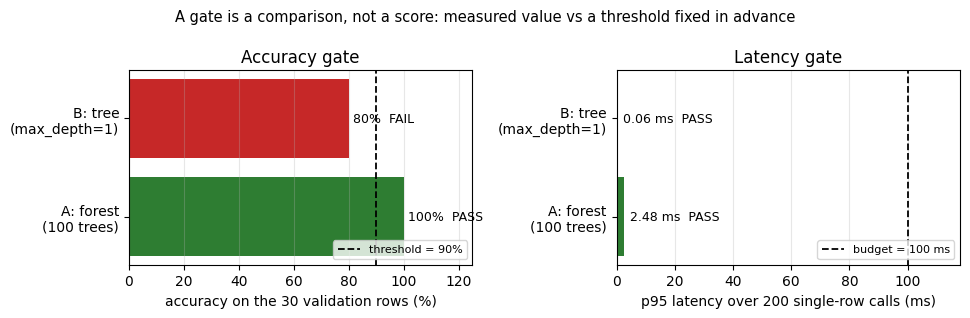

Candidate A (forest, 100 trees) -> APPROVED
Candidate B (depth-1 tree)      -> REJECTED

B is 45x faster per prediction than A (0.06 ms vs 2.48 ms at p95) and still cannot ship.


In [8]:
# WHAT: run the same gate on a deliberately weak candidate, then draw both
# reports as measured-value-vs-threshold bars.
# WHY: a gate you have only ever seen pass teaches nothing. Comparing an approved
# artifact with a rejected one shows what the thresholds are actually doing - and
# which of the two criteria is doing the rejecting.
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Candidate B: same data, same preprocessing, a deliberately under-powered model.
weak_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(max_depth=1, random_state=42)),
])
weak_pipeline.fit(X_train, y_train)

# `result` (candidate A) was produced by the cell above - we reuse it unchanged.
weak_result = validate_model(weak_pipeline, X_val, y_val, CRITERIA)

labels = ["A: forest\n(100 trees)", "B: tree\n(max_depth=1)"]
acc = [result["checks"]["accuracy"]["value"] * 100,
       weak_result["checks"]["accuracy"]["value"] * 100]
lat = [result["checks"]["p95_latency_ms"]["value"],
       weak_result["checks"]["p95_latency_ms"]["value"]]
acc_ok = [result["checks"]["accuracy"]["passed"], weak_result["checks"]["accuracy"]["passed"]]
lat_ok = [result["checks"]["p95_latency_ms"]["passed"], weak_result["checks"]["p95_latency_ms"]["passed"]]
green, red = "#2e7d32", "#c62828"

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.2))

ax = axes[0]
ax.barh(labels, acc, color=[green if ok else red for ok in acc_ok])
ax.axvline(CRITERIA["min_accuracy"] * 100, color="black", ls="--", lw=1.3,
           label=f"threshold = {CRITERIA['min_accuracy']:.0%}")
for i, (v, ok) in enumerate(zip(acc, acc_ok)):
    ax.text(v + 1.5, i, f"{v:.0f}%  {'PASS' if ok else 'FAIL'}", va="center", fontsize=9)
ax.set_xlim(0, 125)
ax.set_xlabel(f"accuracy on the {len(X_val)} validation rows (%)")
ax.set_title("Accuracy gate")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
ax.barh(labels, lat, color=[green if ok else red for ok in lat_ok])
ax.axvline(CRITERIA["max_p95_latency_ms"], color="black", ls="--", lw=1.3,
           label=f"budget = {CRITERIA['max_p95_latency_ms']:.0f} ms")
for i, (v, ok) in enumerate(zip(lat, lat_ok)):
    ax.text(v + 2, i, f"{v:.2f} ms  {'PASS' if ok else 'FAIL'}", va="center", fontsize=9)
ax.set_xlim(0, CRITERIA["max_p95_latency_ms"] * 1.18)
ax.set_xlabel(f"p95 latency over {CRITERIA['n_latency_samples']} single-row calls (ms)")
ax.set_title("Latency gate")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.3)

fig.suptitle("A gate is a comparison, not a score: measured value vs a threshold fixed in advance",
             fontsize=10.5)
plt.tight_layout()
plt.show()

print(f"Candidate A (forest, 100 trees) -> {'APPROVED' if result['passed'] else 'REJECTED'}")
print(f"Candidate B (depth-1 tree)      -> {'APPROVED' if weak_result['passed'] else 'REJECTED'}")
print(f"\nB is {lat[0] / lat[1]:.0f}x faster per prediction than A "
      f"({lat[1]:.2f} ms vs {lat[0]:.2f} ms at p95) and still cannot ship.")

**Read the figure.** Two candidates, two criteria, four bars — and the colours are the whole verdict. Candidate A clears the accuracy threshold (dashed line, left panel) and sits far inside the latency budget (right panel), so `validate_model()` returns `APPROVED`. Candidate B lands to the *left* of the accuracy threshold: one failed check is enough, and the report comes back `REJECTED`.

Now look at the right panel again, because it is the part students usually get backwards. **The rejected model is the fast one** — a single split is enormously cheaper to evaluate than 100 trees, and the printed line says by how much. If you had ranked these two candidates on latency you would have shipped the wrong one. A gate is a conjunction: every criterion must hold at once, and being outstanding on one axis buys nothing on another.

Two honest caveats about the picture you are looking at. Both latency bars are so short against the 100 ms budget that the budget line is barely relevant — on this data, latency is not the binding constraint, and a gate whose thresholds are never close to binding is not testing much. And the accuracy bars rest on 30 validation rows, which is exactly the weakness the "⚠️ Where this breaks" section refuses to let you forget: this picture would look identical whether A is genuinely excellent or merely lucky.

### 7.2  How much is a `PASS` on 30 rows worth?

The gate above returned a single word — `APPROVED` — and a single number, `1.0`. Both were computed from **thirty** validation rows. Before anyone signs off on that, it is worth asking the question the Epic sepsis case makes unavoidable: *what range of true accuracies is consistent with the score we observed?*

A proportion measured on `n` samples has an exact confidence interval (Clopper–Pearson), and it depends only on the count of correct answers and `n` — no simulation, no assumptions about the model. Compute it for both candidates, and then ask how many validation rows the 90% claim would actually need.

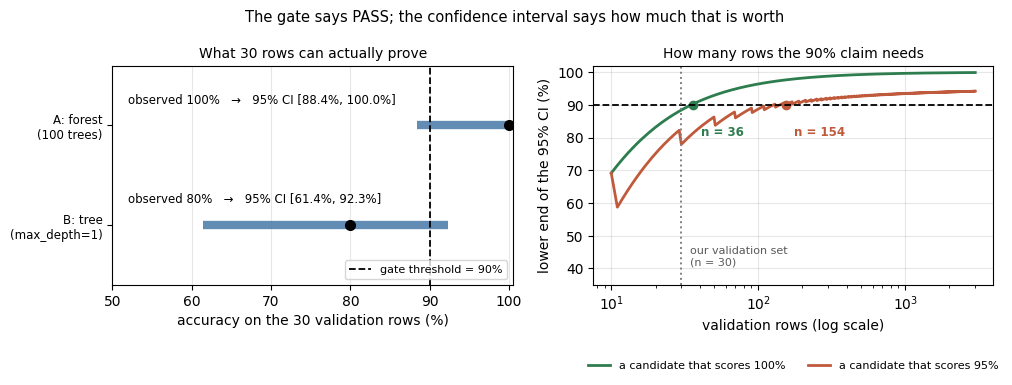

A: forest (100 trees)      30/30 = 100.0%  gate PASS  95% CI [88.4%, 100.0%]   <- interval crosses the threshold
B: tree (max_depth=1)      24/30 =  80.0%  gate FAIL  95% CI [61.4%, 92.3%]   <- interval crosses the threshold


In [9]:
# WHAT: exact 95% confidence intervals for the two candidates' validation accuracy,
# then the number of rows required before a 90% claim is statistically supportable.
# WHY: an accuracy gate compares a POINT ESTIMATE to a threshold. The point estimate
# from 30 rows carries an interval wide enough to sit on both sides of that threshold,
# which means "PASS" and "FAIL" here are partly a statement about sample size.
from scipy.stats import beta

def clopper_pearson(k, n, conf=0.95):
    """Exact binomial CI: k correct out of n. No normal approximation, valid at k == n."""
    a = 1 - conf
    lo = 0.0 if k == 0 else float(beta.ppf(a / 2, k, n - k + 1))
    hi = 1.0 if k == n else float(beta.ppf(1 - a / 2, k + 1, n - k))
    return lo, hi

N_VAL = len(X_val)
THRESH = CRITERIA["min_accuracy"]

# Counts of correct answers, taken from the two reports the gate already produced.
candidates = [
    ("A: forest\n(100 trees)",   round(result["checks"]["accuracy"]["value"] * N_VAL)),
    ("B: tree\n(max_depth=1)",   round(weak_result["checks"]["accuracy"]["value"] * N_VAL)),
]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.2))

# --- left: what our 30 rows can and cannot rule out --------------------------
ax = axes[0]
for i, (label, k) in enumerate(candidates):
    lo, hi = clopper_pearson(k, N_VAL)
    point = k / N_VAL
    y = len(candidates) - 1 - i
    ax.plot([lo * 100, hi * 100], [y, y], color="#4878a8", lw=6,
            solid_capstyle="butt", alpha=0.85)
    ax.plot([point * 100], [y], "o", color="black", ms=7, zorder=3)
    ax.text(52, y + 0.22, f"observed {point:.0%}   \u2192   95% CI [{lo:.1%}, {hi:.1%}]", fontsize=8.5)
ax.axvline(THRESH * 100, color="black", ls="--", lw=1.3, label=f"gate threshold = {THRESH:.0%}")
ax.set_yticks(range(len(candidates)))
ax.set_yticklabels([c[0] for c in candidates][::-1], fontsize=8.5)
ax.set_ylim(-0.6, len(candidates) - 0.4)
ax.set_xlim(50, 100.5)
ax.set_xlabel(f"accuracy on the {N_VAL} validation rows (%)")
ax.set_title(f"What {N_VAL} rows can actually prove", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.3)

# --- right: how the interval tightens as the validation set grows ------------
ax = axes[1]
ns = np.arange(10, 3001)
for rate, color, name in [(1.00, "#2e7d4f", "a candidate that scores 100%"),
                          (0.95, "#c05a3c", "a candidate that scores 95%")]:
    lowers = [clopper_pearson(int(round(rate * n)), n)[0] * 100 for n in ns]
    ax.plot(ns, lowers, color=color, lw=2, label=name)
    # First n from which the lower bound stays above the threshold (20 in a row).
    smallest = next((n for idx, n in enumerate(ns)
                     if all(l >= THRESH * 100 for l in lowers[idx:idx + 20])), None)
    if smallest is not None:
        ax.plot([smallest], [THRESH * 100], "o", color=color, ms=6)
        ax.annotate(f"n = {smallest}", (smallest, THRESH * 100), textcoords="offset points",
                    xytext=(6, -22), fontsize=8.5, color=color, fontweight="bold")
ax.axhline(THRESH * 100, color="black", ls="--", lw=1.3)
ax.axvline(N_VAL, color="grey", ls=":", lw=1.4)
ax.text(N_VAL * 1.15, 41, f"our validation set\n(n = {N_VAL})", fontsize=8, color="0.35")
ax.set_xscale("log")
ax.set_xlabel("validation rows (log scale)")
ax.set_ylabel("lower end of the 95% CI (%)")
ax.set_ylim(35, 102)
ax.set_title(f"How many rows the {THRESH:.0%} claim needs", fontsize=10)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.30), ncol=2, frameon=False)
ax.grid(alpha=0.3)

fig.suptitle("The gate says PASS; the confidence interval says how much that is worth",
             fontsize=10.5)
plt.tight_layout()
plt.show()

for label, k in candidates:
    lo, hi = clopper_pearson(k, N_VAL)
    verdict = "PASS" if k / N_VAL >= THRESH else "FAIL"
    straddles = lo < THRESH <= hi
    print(f"{label.replace(chr(10), ' '):26s} {k:2d}/{N_VAL} = {k / N_VAL:6.1%}  "
          f"gate {verdict}  95% CI [{lo:.1%}, {hi:.1%}]"
          f"{'   <- interval crosses the threshold' if straddles else ''}")

**Read the figure.** Left panel: two thick blue intervals, one per candidate, with the black dot at the score the gate actually used and the dashed line at the 90% threshold.

**Both intervals cross the dashed line.** That is the finding.

- Candidate A scored **30 out of 30** and the gate said `PASS`. Its exact 95% interval runs down to about **88%** — *below* the threshold it just cleared. Thirty perfect answers are not enough to establish that the true accuracy is at least 90%.
- Candidate B scored **24 out of 30** and the gate said `FAIL`. Its interval reaches up past **92%**. The data do not rule out that B would also have met the bar.

The gate produced two confident, opposite verdicts from evidence that supports neither one firmly. Nothing is wrong with the gate code; the validation set is simply too small to carry the decision.

Right panel: the same arithmetic run forwards. The y-axis is the lower end of the 95% interval — the accuracy you can actually *claim* — as the validation set grows along a log x-axis. A model that answers everything correctly needs roughly **35–40 rows** before that lower bound clears 90%; a model that scores 95% needs **on the order of 150**. The dotted vertical line marks where our thirty rows sit: to the left of both crossings.

The practical rule this gives you: **the size of the validation set is part of the acceptance criteria, and it should be written down in section 2 alongside the thresholds.** A gate that can pass on thirty rows is a gate that can pass by luck. Note that this widens rather than replaces the "⚠️ Where this breaks" warning below: a large validation set drawn from the *wrong population* still produces a tight interval around the wrong number, which is precisely what happened to the Epic sepsis model.

## 💬 Discuss

Look carefully at what the malformed-input probe actually printed. Two of three bad inputs raised a `ValueError`. The **NaN row did not**: the pipeline returned `[0]` — a real class prediction, from a row containing no information at all. Our `validate_model()` gate then reported `"no_nan_output": {"passed": true}`, because it checks NaN in the *output*, not the *input*.

1. Is that a bug in the model, in the gate, or in our understanding of what the gate is for? Would you add an input-NaN check here, at the API layer, or in monitoring — and what does each choice cost?
2. Our accuracy gate is 90% and the model scored 100% on 30 validation samples. What is the narrowest confidence interval you would honestly claim from 30 samples? Given the Epic case above, would you sign off on this model, and what would you write next to your signature?
3. The criteria were fixed *before* the run — a deliberate anti-p-hacking move. Now suppose the model comes back at 89.5% against a 90% threshold and the launch date is Sunday. Who is allowed to change the threshold, when, and on what evidence? Write the rule you would actually be willing to defend to a regulator.

## Summary

Pre-deployment validation is a formal gate, not an exploration. Key points:

| Check | What it catches |
|---|---|
| Accuracy on held-out validation set | Model doesn't generalize to new data |
| p95 latency < threshold | Model is too slow for real-time use |
| No NaN in outputs | Numerical instability that would break downstream systems |

Set criteria **before** running validation. Use `validate_model()` as the final checkpoint before any deployment script is triggered.


## Self-check

1. **What accuracy threshold would you set for a fraud detection model vs an Iris classifier?** Consider the cost of a false negative (missed fraud) vs a false positive (blocking a real customer) — and how that should change your threshold.
2. **Why check p95 latency rather than mean latency?** Look at the latency numbers printed above — how different are p50 and p95? Which number would users actually experience?
3. **What does it mean if the model passes accuracy tests but fails latency tests?** Think about what options you have: change the model architecture, optimize the preprocessing, or change the serving infrastructure.


## ⚠️ Where this breaks

A gate is only as honest as the data behind it, and this one is running on 30 iris rows.

- **The gate cannot outperform its validation set.** Thirty samples of a famously separable dataset cannot distinguish an excellent model from a lucky one, and 100% accuracy is a warning sign, not a result. The Epic sepsis model passed *its* vendor evaluation too; what it never had was a gate run on the population that would actually be scored. **Match your validation set to the deployment population, or the gate is theatre.**
- **`predict()` is not the whole system.** We measured p95 latency at a few milliseconds for `model.predict()` alone — read the exact number off the latency cell above. Production latency includes JSON parsing, feature lookup, network, and any feature store the model depends on — often the majority of the budget. A gate on the model alone can pass while the service misses its SLO by 10×.
- **NaN in, prediction out.** Shown above: scikit-learn's forest tolerates missing values and returned class `0` for an all-NaN row without complaint. Any gate you build should be assumed to have exactly this kind of hole until you have deliberately probed for it.
- **The assumption that must hold:** the artifact on disk is the artifact that will be served. We load `MODEL_PATH` and validate it — but nothing stops a later step from deploying a different file. Only content-addressed artifacts (a hash in CI, Unit 4 notebook 04) make that assumption true rather than hopeful.
- **Where a threshold gate is the wrong tool entirely.** For a strongly imbalanced problem — fraud, sepsis, equipment failure — a single accuracy threshold is close to meaningless: predicting "no event" always can clear 99%. Gate on recall at a fixed precision, on cost-weighted error, or on per-subgroup performance. And when the cost of a false negative is measured in lives rather than dollars, an automated gate is a filter, not a decision: a human sign-off with the numbers in front of them is the cheaper, safer alternative.

## 📚 References

1. Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). *The ML Test Score: A Rubric for ML Production Readiness and Technical Debt Reduction*. IEEE Big Data. <https://research.google/pubs/the-ml-test-score-a-rubric-for-ml-production-readiness-and-technical-debt-reduction/>
2. Ribeiro, M. T., Wu, T., Guestrin, C., & Singh, S. (2020). *Beyond Accuracy: Behavioral Testing of NLP Models with CheckList*. ACL. <https://arxiv.org/abs/2005.04118>
3. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
4. Li, Z., Ko, Y., Keramati, A., et al. (2026). *One Success Isn't Reliability: Thinkingbox, a Sandbox and Benchmark for Agents in Stateful Business Workflows*. arXiv:2608.19741. <https://arxiv.org/abs/2608.19741>
5. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv:2606.09809. <https://arxiv.org/abs/2606.09809>
